<a href="https://colab.research.google.com/github/vsharitha99-de/customer-churn-prediction/blob/main/notebooks/churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CUSTOMER** **CHURN** **PREDICTING**  :**CLASSIFICATION** **ANALYSIS**

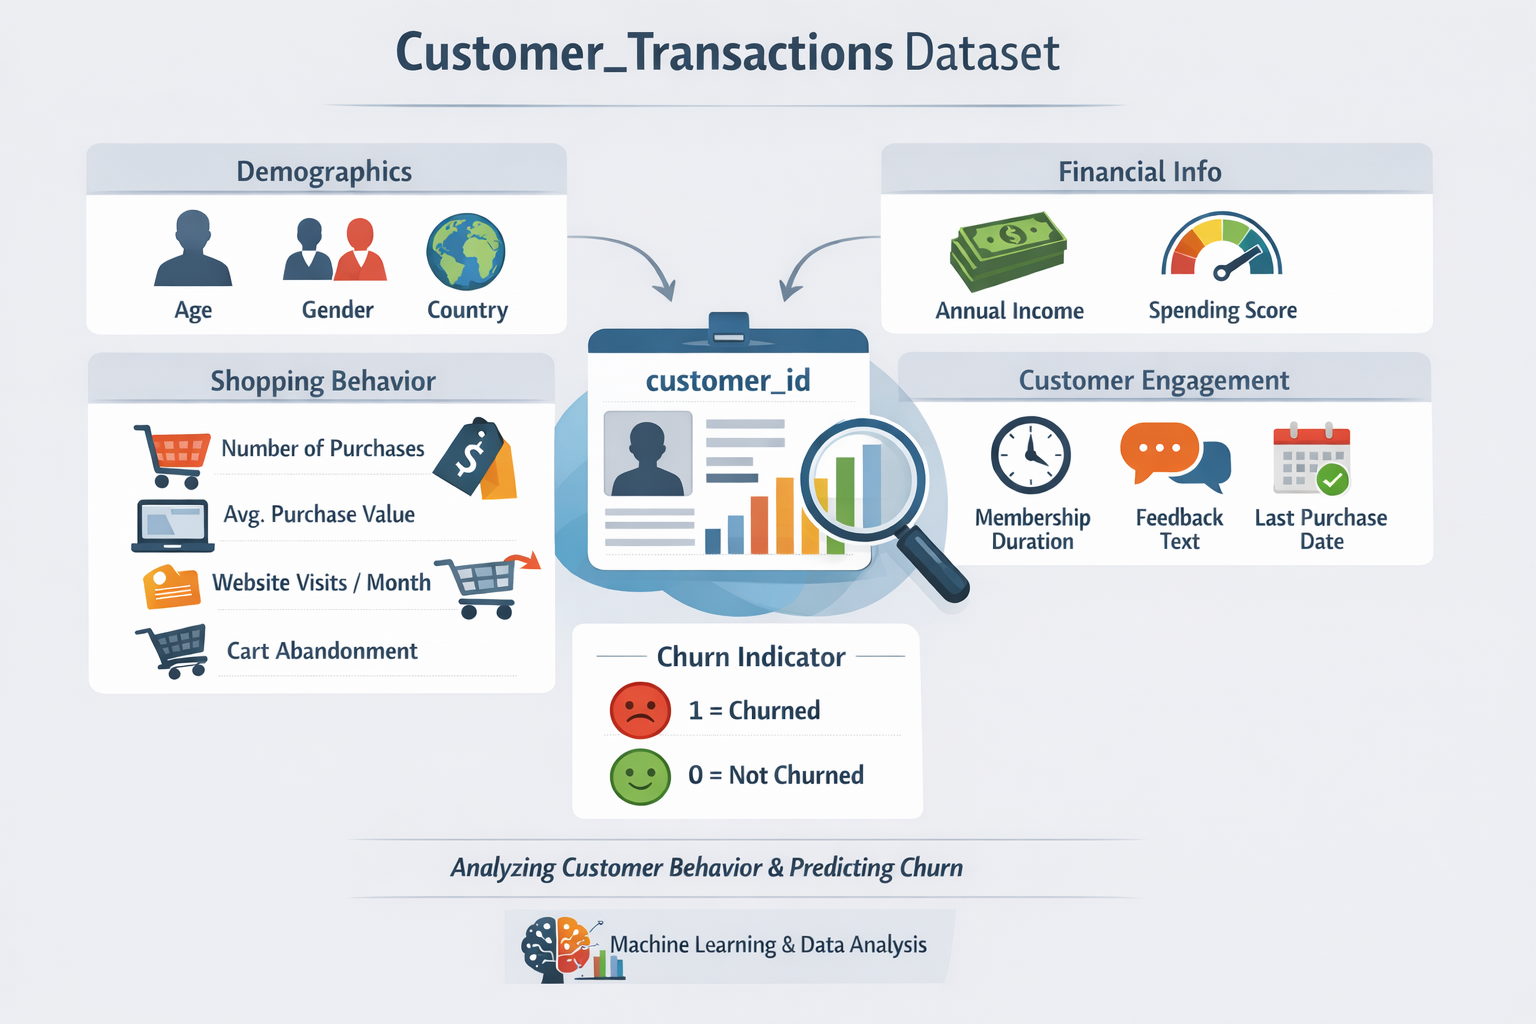

This project focuses on using classification analysis to predict customer churn based on demographic, financial, and behavioral data. By analyzing attributes such as age, gender, income, spending patterns, website engagement, and purchase behavior, the model identifies customers who are likely to stop using the service. The results of this analysis help businesses understand customer behavior, improve retention strategies, and make data-driven decisions.

# IMPORTING SUFFICIENT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')







# DATA SET LOADING

In [2]:
ct=pd.read_csv("/content/drive/MyDrive/Customer_Transactions.csv")
ct

,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date
0,1,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,Very satisfied with my purchase.,2025-06-22
1,2,40,Male,India,41041,4,10,31.73,4,29,0.21,0,Good quality and value for money.,2025-10-17
2,3,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,Excellent customer service.,2025-07-01
3,4,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,Good quality and value for money.,2025-08-17
4,5,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,Excellent customer service.,2025-06-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,39,Female,France,45002,39,13,45.50,4,28,0.75,0,Excellent customer service.,2025-08-06
9996,9997,44,Male,USA,95367,86,41,54.22,13,17,0.19,0,"Great experience, will shop again!",2025-08-15
9997,9998,25,Female,USA,73884,33,17,49.58,4,1,0.71,0,Love the products and fast shipping.,2025-10-26
9998,9999,19,Female,USA,80849,85,12,49.20,0,18,0.33,0,Excellent customer service.,2025-09-16


# DATA PREPROCESSING

In [3]:
ct.drop_duplicates(inplace=True)

In [4]:
ct.drop(["customer_id","feedback_text"],axis=1,inplace=True)

In [5]:
ct

,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,last_purchase_date
0,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,2025-06-22
1,40,Male,India,41041,4,10,31.73,4,29,0.21,0,2025-10-17
2,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,2025-07-01
3,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,2025-08-17
4,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,2025-06-21
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,39,Female,France,45002,39,13,45.50,4,28,0.75,0,2025-08-06
9996,44,Male,USA,95367,86,41,54.22,13,17,0.19,0,2025-08-15
9997,25,Female,USA,73884,33,17,49.58,4,1,0.71,0,2025-10-26
9998,19,Female,USA,80849,85,12,49.20,0,18,0.33,0,2025-09-16


In [6]:
ct.isna().sum()

,0
age,0
gender,0
country,0
annual_income,0
spending_score,0
num_purchases,0
avg_purchase_value,0
membership_years,0
website_visits_per_month,0
cart_abandon_rate,0


In [ ]:
ct.dtypes

,0
age,int64
gender,object
country,object
annual_income,int64
spending_score,int64
num_purchases,int64
avg_purchase_value,float64
membership_years,int64
website_visits_per_month,int64
cart_abandon_rate,float64


# VISUALIZATION

In [7]:
ct["churned"].unique()

array([0, 1])

<Axes: xlabel='churned', ylabel='count'>

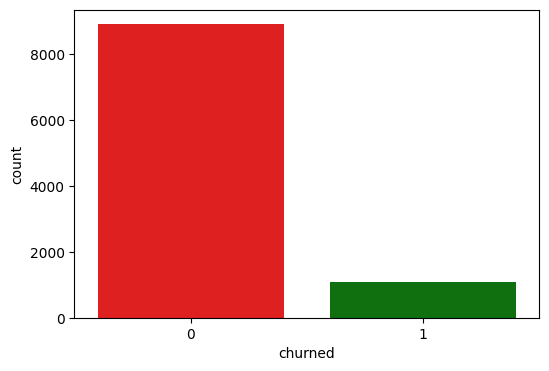

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='churned',data=ct,palette=["red","green"])


In [9]:
ct['gender'].value_counts()

,count
gender,
Male,5063
Female,4937


<Axes: xlabel='gender', ylabel='count'>

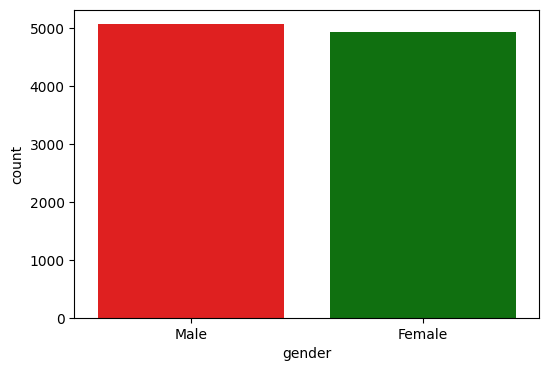

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender',data=ct,palette=["red","green"])

In [11]:
ct

,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,last_purchase_date
0,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,2025-06-22
1,40,Male,India,41041,4,10,31.73,4,29,0.21,0,2025-10-17
2,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,2025-07-01
3,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,2025-08-17
4,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,2025-06-21
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,39,Female,France,45002,39,13,45.50,4,28,0.75,0,2025-08-06
9996,44,Male,USA,95367,86,41,54.22,13,17,0.19,0,2025-08-15
9997,25,Female,USA,73884,33,17,49.58,4,1,0.71,0,2025-10-26
9998,19,Female,USA,80849,85,12,49.20,0,18,0.33,0,2025-09-16


In [12]:
ct.dtypes

,0
age,int64
gender,object
country,object
annual_income,int64
spending_score,int64
num_purchases,int64
avg_purchase_value,float64
membership_years,int64
website_visits_per_month,int64
cart_abandon_rate,float64


# CONVERTING DATATYPES USING LABELENCODING

In [13]:
encoder=LabelEncoder()
# Encode valid categorical columns
ct["gender"] = encoder.fit_transform(ct["gender"])
ct["country"] = encoder.fit_transform(ct["country"])
# Convert to datetime
ct['last_purchase_date'] = pd.to_datetime(ct['last_purchase_date'])

# Choose a reference date (usually max date in dataset)
reference_date = ct['last_purchase_date'].max()

# Create new feature
ct['days_since_last_purchase'] = (reference_date -ct['last_purchase_date']).dt.days

# Drop original column
ct.drop('last_purchase_date', axis=1, inplace=True)

In [14]:
ct

,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,days_since_last_purchase
0,37,1,4,85886,14,18,41.20,6,20,0.95,0,127
1,40,1,5,41041,4,10,31.73,4,29,0.21,0,10
2,69,0,0,143869,59,39,65.96,12,26,0.08,0,118
3,30,1,8,87261,45,34,51.87,12,7,0.61,0,71
4,69,0,8,110678,40,38,59.64,13,16,0.49,0,128
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,39,0,3,45002,39,13,45.50,4,28,0.75,0,82
9996,44,1,9,95367,86,41,54.22,13,17,0.19,0,73
9997,25,0,9,73884,33,17,49.58,4,1,0.71,0,1
9998,19,0,9,80849,85,12,49.20,0,18,0.33,0,41


In [15]:
ct.dtypes

,0
age,int64
gender,int64
country,int64
annual_income,int64
spending_score,int64
num_purchases,int64
avg_purchase_value,float64
membership_years,int64
website_visits_per_month,int64
cart_abandon_rate,float64


# SEPARATING FEATURES AND TARGETS

In [16]:
x=ct.drop(["churned"],axis=1)
x

,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,days_since_last_purchase
0,37,1,4,85886,14,18,41.20,6,20,0.95,127
1,40,1,5,41041,4,10,31.73,4,29,0.21,10
2,69,0,0,143869,59,39,65.96,12,26,0.08,118
3,30,1,8,87261,45,34,51.87,12,7,0.61,71
4,69,0,8,110678,40,38,59.64,13,16,0.49,128
...,...,...,...,...,...,...,...,...,...,...,...
9995,39,0,3,45002,39,13,45.50,4,28,0.75,82
9996,44,1,9,95367,86,41,54.22,13,17,0.19,73
9997,25,0,9,73884,33,17,49.58,4,1,0.71,1
9998,19,0,9,80849,85,12,49.20,0,18,0.33,41


In [17]:
y=ct["churned"]
y

,churned
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


# SCALING


In [18]:
scaler=MinMaxScaler()
scaler.fit(x)

MinMaxScaler()

In [19]:
x_scaled=scaler.transform(x)
x_scaled

array([[0.36538462, 1.        , 0.44444444, ..., 0.65517241, 0.95      ,
        0.17469051],
       [0.42307692, 1.        , 0.55555556, ..., 0.96551724, 0.21      ,
        0.01375516],
       [0.98076923, 0.        , 0.        , ..., 0.86206897, 0.08      ,
        0.16231087],
       ...,
       [0.13461538, 0.        , 1.        , ..., 0.        , 0.71      ,
        0.00137552],
       [0.01923077, 0.        , 1.        , ..., 0.5862069 , 0.33      ,
        0.05639615],
       [0.92307692, 1.        , 0.55555556, ..., 0.37931034, 0.67      ,
        0.18431912]])

# TRAIN TEST SPLIT

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=1)

In [21]:
x_train.shape,y_train.shape

((7000, 11), (7000,))

In [22]:
x_test.shape,y_test.shape

((3000, 11), (3000,))

# MODEL SELECTION

In [23]:
knn=KNeighborsClassifier(n_neighbors=3)
sv=SVC(kernel="poly")
nb=GaussianNB()
dt=DecisionTreeClassifier()
rf=RandomForestClassifier()
ab=AdaBoostClassifier()
xgb=XGBClassifier()


# PERFORMANCE MEASURES

In [24]:
models=[knn,sv,nb,dt,rf,ab,xgb]
for model in models:
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  print("         ",model,"      ")
  print(classification_report(y_test,y_pred))

          KNeighborsClassifier(n_neighbors=3)       
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2670
           1       0.98      0.68      0.81       330

    accuracy                           0.96      3000
   macro avg       0.97      0.84      0.89      3000
weighted avg       0.96      0.96      0.96      3000

          SVC(kernel='poly')       
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2670
           1       0.99      0.93      0.96       330

    accuracy                           0.99      3000
   macro avg       0.99      0.96      0.98      3000
weighted avg       0.99      0.99      0.99      3000

          GaussianNB()       
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2670
           1       1.00      0.92      0.96       330

    accuracy                           0.99      3000
   macro 

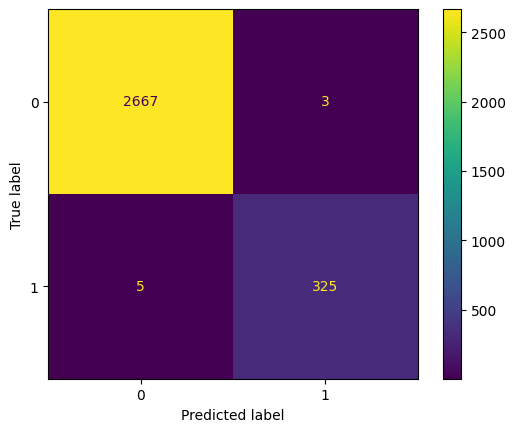

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [26]:
corr = ct[['days_since_last_purchase', 'churned']].corr()
print(corr)

                          days_since_last_purchase   churned
days_since_last_purchase                  1.000000  0.844885
churned                                   0.844885  1.000000


In [27]:
ct.groupby('churned')['days_since_last_purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
churned,,,,,,,,
0,8910.0,89.043098,51.778266,0.0,44.00,89.0,134.0,178.0
1,1090.0,451.285321,158.053716,179.0,319.25,449.0,585.0,727.0


*The* feature days_since_last_purchase created a perfect separation between churned and non-churned customers, leading to 100% accuracy. I removed it to avoid overfitting and ensure realistic predictions.

# REMOVING THE FEATURE **days_since_last_purchase**

In [28]:
ct.drop(["days_since_last_purchase"],axis=1,inplace=True)

In [29]:
ct

,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned
0,37,1,4,85886,14,18,41.20,6,20,0.95,0
1,40,1,5,41041,4,10,31.73,4,29,0.21,0
2,69,0,0,143869,59,39,65.96,12,26,0.08,0
3,30,1,8,87261,45,34,51.87,12,7,0.61,0
4,69,0,8,110678,40,38,59.64,13,16,0.49,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,39,0,3,45002,39,13,45.50,4,28,0.75,0
9996,44,1,9,95367,86,41,54.22,13,17,0.19,0
9997,25,0,9,73884,33,17,49.58,4,1,0.71,0
9998,19,0,9,80849,85,12,49.20,0,18,0.33,0


In [30]:
#Separating Features and Targets
x=ct.drop(["churned"],axis=1)
x
y=ct["churned"]
y
#Scaling and Train_Test_Split
scaler.fit(x)
x_scaled=scaler.transform(x)
x_scaled
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=1)
x_train.shape,y_train.shape
x_test.shape,y_test.shape
#Model Creation
knn=KNeighborsClassifier(n_neighbors=3)
sv=SVC(kernel="poly")
nb=GaussianNB()
dt=DecisionTreeClassifier()
rf=RandomForestClassifier()
ab=AdaBoostClassifier()
xgb=XGBClassifier()
#Performance Measures
models=[knn,sv,nb,dt,rf,ab,xgb]
for model in models:
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  print("         ",model,"      ")
  print(classification_report(y_test,y_pred))


          KNeighborsClassifier(n_neighbors=3)       
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      2670
           1       0.29      0.14      0.19       330

    accuracy                           0.87      3000
   macro avg       0.59      0.55      0.56      3000
weighted avg       0.83      0.87      0.85      3000

          SVC(kernel='poly')       
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      2670
           1       0.00      0.00      0.00       330

    accuracy                           0.89      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.79      0.89      0.84      3000

          GaussianNB()       
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2670
           1       0.26      0.17      0.20       330

    accuracy                           0.86      3000
   macro 

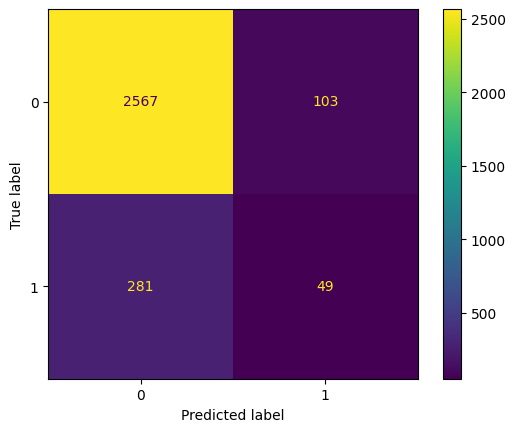

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

# CHANGING IMBALANCED DATASET INTO BALANCED DATASET USING OVER_SAMPLING


In [32]:
ct['churned'].value_counts()

,count
churned,
0,8910
1,1090


# OVER_SAMPLING

In [33]:
os= SMOTE()
x_os,y_os = os.fit_resample(x,y)

In [34]:
x_os.shape

(17820, 10)

In [35]:
y_os

,churned
0,0
1,0
2,0
3,0
4,0
...,...
17815,1
17816,1
17817,1
17818,1


In [36]:
y_os.shape

(17820,)

In [37]:
y_os.value_counts()

,count
churned,
0,8910
1,8910


In [38]:
x_os_scaled=scaler.fit_transform(x_os)
x_os_scaled

array([[0.36538462, 1.        , 0.44444444, ..., 0.4       , 0.65517241,
        0.95      ],
       [0.42307692, 1.        , 0.55555556, ..., 0.26666667, 0.96551724,
        0.21      ],
       [0.98076923, 0.        , 0.        , ..., 0.8       , 0.86206897,
        0.08      ],
       ...,
       [0.80769231, 1.        , 0.88888889, ..., 0.2       , 0.48275862,
        0.79274699],
       [0.34615385, 0.        , 0.11111111, ..., 0.86666667, 0.5862069 ,
        0.59938802],
       [0.63461538, 0.        , 0.88888889, ..., 0.6       , 0.31034483,
        0.69860882]])

In [39]:
x_os_train,x_os_test,y_os_train,y_os_test=train_test_split(x_os_scaled,y_os,test_size=0.3,random_state=1)

In [40]:
models=[knn,sv,nb,dt,rf,ab,xgb]
for model in models:
    model.fit(x_os_train, y_os_train)   # train on SMOTE data

    y_pred = model.predict(x_test)      # test on original

    print("         ", model, "      ")
    print(classification_report(y_test, y_pred))

          KNeighborsClassifier(n_neighbors=3)       
              precision    recall  f1-score   support

           0       0.99      0.78      0.87      2670
           1       0.35      0.94      0.51       330

    accuracy                           0.80      3000
   macro avg       0.67      0.86      0.69      3000
weighted avg       0.92      0.80      0.83      3000

          SVC(kernel='poly')       
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      2670
           1       0.23      0.68      0.35       330

    accuracy                           0.72      3000
   macro avg       0.59      0.70      0.58      3000
weighted avg       0.87      0.72      0.77      3000

          GaussianNB()       
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      2670
           1       0.21      0.64      0.32       330

    accuracy                           0.70      3000
   macro 

# FEATURE SELECTION

In [41]:
ct.corr()

,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned
age,1.000000,-0.005400,-0.006337,0.158097,0.004362,0.346444,0.116817,0.342298,-0.007362,0.011224,-0.028829
gender,-0.005400,1.000000,0.000262,-0.009340,0.000430,-0.003489,-0.004198,-0.001365,0.012712,-0.003345,0.010354
country,-0.006337,0.000262,1.000000,0.200944,0.001952,0.043680,0.138449,0.003986,-0.008482,0.007813,0.003473
annual_income,0.158097,-0.009340,0.200944,1.000000,-0.002469,0.238506,0.685930,0.053070,-0.019219,-0.005011,-0.003805
spending_score,0.004362,0.000430,0.001952,-0.002469,1.000000,0.288284,0.513464,0.006261,-0.007743,-0.003125,-0.244574
num_purchases,0.346444,-0.003489,0.043680,0.238506,0.288284,1.000000,0.310879,0.933037,-0.021605,-0.003646,-0.173775
avg_purchase_value,0.116817,-0.004198,0.138449,0.685930,0.513464,0.310879,1.000000,0.038625,-0.011991,-0.004648,-0.130213
membership_years,0.342298,-0.001365,0.003986,0.053070,0.006261,0.933037,0.038625,1.000000,-0.017148,-0.001755,-0.109910
website_visits_per_month,-0.007362,0.012712,-0.008482,-0.019219,-0.007743,-0.021605,-0.011991,-0.017148,1.000000,0.017389,-0.124727
cart_abandon_rate,0.011224,-0.003345,0.007813,-0.005011,-0.003125,-0.003646,-0.004648,-0.001755,0.017389,1.000000,0.160703


In [42]:
x1=x_os.drop(["age","gender","country","annual_income","membership_years"],axis=1)

In [43]:
scaler.fit(x1)
x1_scaled=scaler.transform(x1)

In [44]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1_scaled,y_os,test_size=0.2,random_state=1)

In [45]:
models=[knn,sv,nb,dt,rf,ab,xgb]
for model in models:
   print("             ",model,"             ")
   model.fit(x1_train,y1_train)
   y1_pred=model.predict(x1_test)
   print(classification_report(y1_test,y1_pred))

              KNeighborsClassifier(n_neighbors=3)              
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      1753
           1       0.76      0.88      0.81      1811

    accuracy                           0.80      3564
   macro avg       0.80      0.79      0.79      3564
weighted avg       0.80      0.80      0.79      3564

              SVC(kernel='poly')              
              precision    recall  f1-score   support

           0       0.88      0.63      0.74      1753
           1       0.72      0.92      0.81      1811

    accuracy                           0.78      3564
   macro avg       0.80      0.78      0.77      3564
weighted avg       0.80      0.78      0.77      3564

              GaussianNB()              
              precision    recall  f1-score   support

           0       0.78      0.70      0.74      1753
           1       0.74      0.81      0.77      1811

    accuracy                  

# HYPER PARAMETER TUNNING

In [46]:
x_train_s = StandardScaler().fit_transform(x_train)
x_train_os, y_train_os = SMOTE(random_state=42).fit_resample(x_train_s,y_train)
knngrid = RandomizedSearchCV(KNeighborsClassifier(), {'n_neighbors':[3,5,7,9,11],'weights':['uniform','distance'],'p':[1,2]}, n_iter=8, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
knngrid.fit(x_train_os, y_train_os)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_iter=8, n_jobs=-1,
                   param_distributions={'n_neighbors': [3, 5, 7, 9, 11],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   random_state=42, scoring='roc_auc')

In [47]:
print(knngrid.best_params_)

{'weights': 'distance', 'p': 1, 'n_neighbors': 11}


In [48]:
scaler = StandardScaler().fit(x_train)
x_train_s = scaler.transform(x_train)
x_train_os, y_train_os = SMOTE(random_state=42).fit_resample(x_train_s, y_train)

# Add class_weight='balanced' + better C range
svparams = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1],
    'kernel': ['rbf'],
    'class_weight': ['balanced']       # Force SVM to care about churn
}

svgrid = RandomizedSearchCV(SVC(probability=True,random_state=42), {'kernel':['rbf'],'C':[0.1,1,10,100],'gamma':['scale',0.1]}, n_iter=8, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
svgrid.fit(x_train_os, y_train_os)


RandomizedSearchCV(cv=5, estimator=SVC(probability=True, random_state=42),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'gamma': ['scale', 0.1],
                                        'kernel': ['rbf']},
                   random_state=42, scoring='roc_auc')

In [49]:
print(svgrid.best_params_)

{'kernel': 'rbf', 'gamma': 'scale', 'C': 100}


In [50]:
x_train_os, y_train_os = SMOTE(random_state=42).fit_resample(x_train, y_train)
nbgrid = RandomizedSearchCV(GaussianNB(), {'var_smoothing':[1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]}, n_iter=8, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
nbgrid.fit(x_train_os,y_train_os)
print("Best params:", nbgrid.best_params_)

Best params: {'var_smoothing': 1}


In [51]:
print(nbgrid.best_params_)

{'var_smoothing': 1}


In [52]:
x_train_os, y_train_os = SMOTE(random_state=42).fit_resample(x_train, y_train)
dtgrid = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), {'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':[3,5,7,10,15,None],'min_samples_split':[2,5,10]}, n_iter=10, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
dtgrid.fit(x_train_os, y_train_os)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10, 15, None],
                                        'min_samples_split': [2, 5, 10],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [53]:
print(dtgrid.best_params_)

{'splitter': 'best', 'min_samples_split': 10, 'max_depth': 15, 'criterion': 'gini'}


In [54]:
x_train_os, y_train_os = SMOTE(random_state=42).fit_resample(x_train, y_train)
rfgrid = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), {'n_estimators':[50,100,150,200],'criterion':['gini','entropy'],'max_depth':[5,10,15,20,None],'min_samples_split':[2,5,10]}, n_iter=12, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
rfgrid.fit(x_train_os, y_train_os)


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 10, 15, 20, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200]},
                   random_state=42, scoring='roc_auc')

In [55]:
print(rfgrid.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None, 'criterion': 'gini'}


In [56]:
x_train_os, y_train_os = SMOTE(random_state=42).fit_resample(x_train, y_train)
abgrid = RandomizedSearchCV(AdaBoostClassifier(random_state=42), {'n_estimators':[50,100,200,300],'learning_rate':[0.01,0.1,0.5,1.0,2.0]}, n_iter=8, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
abgrid.fit(x_train_os, y_train_os)

RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5, 1.0,
                                                          2.0],
                                        'n_estimators': [50, 100, 200, 300]},
                   random_state=42, scoring='roc_auc')

In [57]:
print(abgrid.best_params_)

{'n_estimators': 300, 'learning_rate': 1.0}


In [58]:
x_train_os, y_train_os = SMOTE(random_state=42).fit_resample(x_train, y_train)
xggrid = RandomizedSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), {'n_estimators':[100,200,300,500],'learning_rate':[0.01,0.05,0.1,0.2,0.3],'max_depth':[3,5,7,10],'subsample':[0.6,0.8,1.0],'colsample_bytree':[0.6,0.8,1.0]}, n_iter=12, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
xggrid.fit(x_train_os, y_train_os)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc')

In [59]:
print(xggrid.best_params_)

{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.3, 'colsample_bytree': 1.0}


In [60]:
knn1=KNeighborsClassifier(weights='distance',p=1,n_neighbors= 11)
sv1=SVC(kernel= 'rbf', gamma='scale', C= 100)
nb1=GaussianNB(var_smoothing=1)
dt1=DecisionTreeClassifier(splitter='best',min_samples_split= 10, max_depth= 15, criterion='gini')
rf1=RandomForestClassifier(n_estimators=200,min_samples_split= 5,max_depth= None, criterion='gini')
ab1=AdaBoostClassifier(n_estimators= 300, learning_rate= 1.0)
xgb1=XGBClassifier(subsample=0.8, n_estimators= 500,max_depth= 7,learning_rate= 0.3, colsample_bytree= 1.0)

In [61]:
models1=[knn1,sv1,nb1,dt1,rf1,ab1,xgb1]
models_scaling = [knn1, sv1]
scaler_for_prediction = StandardScaler()
scaler_for_prediction.fit(x_train)
x_test_s = scaler_for_prediction.transform(x_test)

# Prepare scaled and SMOTE-oversampled training data for models that need scaling
x_train_scaled_for_fitting = scaler_for_prediction.transform(x_train)
x_train_scaled_os, y_train_scaled_os = SMOTE(random_state=42).fit_resample(x_train_scaled_for_fitting, y_train)

for model in models1:
    if model in models_scaling:
        model.fit(x_train_scaled_os, y_train_scaled_os)
        y_pred = model.predict(x_test_s)
    else:
        model.fit(x_train_os, y_train_os)
        y_pred = model.predict(x_test)

    print("         ",model,"      ")
    print(classification_report(y_test,y_pred))

          KNeighborsClassifier(n_neighbors=11, p=1, weights='distance')       
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      2670
           1       0.21      0.63      0.32       330

    accuracy                           0.70      3000
   macro avg       0.58      0.67      0.56      3000
weighted avg       0.86      0.70      0.75      3000

          SVC(C=100)       
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      2670
           1       0.23      0.38      0.29       330

    accuracy                           0.79      3000
   macro avg       0.57      0.61      0.58      3000
weighted avg       0.84      0.79      0.81      3000

          GaussianNB(var_smoothing=1)       
              precision    recall  f1-score   support

           0       0.96      0.61      0.75      2670
           1       0.20      0.80      0.32       330

    accuracy                  

# **After evaluating multiple models, GaussianNB achieved the highest accuracy of 89%, but XGBoost and KNN showed the best churn detection with F1=0.35 and recall=0.63 respectively. Due to class imbalance, accuracy alone proved misleading for evaluating churn prediction performance.**